In [1]:
import ucdmcmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("/Users/epritchard/Research/")
import TAPS
import emcee
import scipy.interpolate



Welcome to the UCDMCMC spectral fitting code!
This code is designed to conduct both grid and MCMC fitting of spectral data of ultracool dwarfs
You are currently using version dated 2026.04.03

If you make use of this code for your research, please remember to cite our Zenodo DOI:
	10.5281/zenodo.16923762 (https://doi.org/10.5281/zenodo.16923762)
If you make use of any spectra or models in this toolkit, please remember to cite the original source.
Please report any errors are feature requests to our github page, http://www.github.com/aburgasser/ucdmcmc/


Currently running in error checking mode


Welcome to the Spex Prism Library Analysis Toolkit (SPLAT)!
You are currently using version 2025.12.26

If you make use of any features of this toolkit for your research, please remember to cite the SPLAT paper:

Burgasser et al. (2017, Astro. Soc. India Conf. Series 14, p. 7); Bibcode: 2017ASInC..14....7B

If you make use of any spectra or models in this toolkit, please remember to cite the

# Set Up!
Main things needed for emcee are:
- a callable function for the log posterior
- a way to interpolate the models (not extra grid points but also callable)

# Robust Model Interpolation!
First we need to interpolate the models! Im gonna see if i can do this with just one parameter for now then see if we can scale it up with more parameters!

In [12]:
# Initlizing some example JWST spectra from TAPS standards (using TAPS)
T3_spec = TAPS.standardset_TAPS[9]
L1_spec = TAPS.standardset_TAPS[16]
M6_spec = TAPS.standardset_TAPS[12]

# A modelset to try fitting to JWST spectra above!
models, wave = ucdmcmc.getModelSet(modelset='sand24',instrument='JWST-NIRSPEC-PRISM')
models

,model,enrich,logg,teff,z,flux
0,sand24,-0.00,2.5,3700.0,-0.60,"[1444246008.7582908, 3076205562.136547, 328925..."
1,sand24,0.30,5.0,3800.0,-1.95,"[2506564539.1410356, 5169580506.509935, 525560..."
2,sand24,-0.05,4.5,3800.0,-0.15,"[2119409563.2527304, 4473889911.069309, 474168..."
3,sand24,0.15,5.5,3800.0,-1.30,"[2372690870.926221, 4951119117.875883, 5072902..."
4,sand24,0.20,4.5,3800.0,-0.60,"[2288810465.3509746, 4781220604.646603, 497832..."
...,...,...,...,...,...,...
5596,sand24,-0.05,2.5,3000.0,-0.15,"[66334053.663734704, 176385930.15171537, 30665..."
5597,sand24,0.20,2.0,3000.0,-0.35,"[39634258.14796887, 115703907.14576408, 230468..."
5598,sand24,0.15,4.5,3000.0,-0.15,"[169520441.22796565, 391449224.1279504, 530107..."
5599,sand24,-0.00,4.5,3000.0,0.30,"[149256977.6019265, 342624824.72165775, 470013..."


In [4]:
# We're gonna test with a varying temperature first! 
# We'll do this by making a mask and keeping all other parameters constant!
mask = (models["enrich"] == -0.00) & (models["logg"] == 4.5) & (models["z"] == 0.10) 

# Then we apply the mask and for clarity sort the models in order of increasing t_eff
sorted_model_array = models[mask].sort_values("teff")

# With the data sorted, we make the columns into numpy arrays so that our interpolator knows how to read them!
# note, I'm making each array their own object cause I thought it'd be easier to manipulate
teff_array = np.array(sorted_model_array["teff"]) # 34 t_eff values
flux_array = np.array(sorted_model_array["flux"])

# note: there was already a wavelength range but it was a astropy quantity so turned it back to a numpy array incase of bugs
wave_array = wave.value # 1001 wave values (from 0.5 to 6.0 microns)

# The different spectra are stored in a 1d array (i.e. flux_array[0] contains a 1d array with the flux values for t_eff==700, from 0.5-6.0 microns)
# To "unravel" the arrays, we use np.stack which extends the 1d arrays along the rows, making an array with shape (34 rows, 1001 columns)
values = np.stack(flux_array)

# Now we use scipy's RegularGridInterpolator(points, values)
# points needs our 1d arrays of parameters (teff_array and wave_array) 
# values needs our flux values, matching the dimensions / corresponding to our parameter vectors
# with those, we initialize interp(), a callable function which allows us to infinitely interpolate wavelength values between grid points!
interp = scipy.interpolate.RegularGridInterpolator((teff_array, wave_array), values=values)

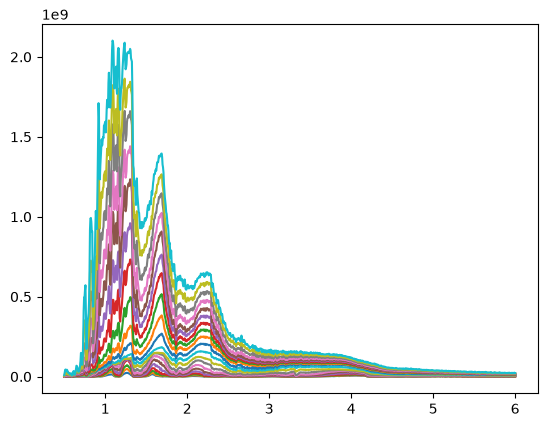

In [5]:
# Calling interp() creates interpolated spectra yayyyy!!!
test_T = np.linspace(700, 2500, 20)
for T in test_T:
    glorp = interp((T, wave_array))
    plt.plot(wave_array, glorp)

__Now Lets include another parameter!__

       model  enrich  logg    teff     z  \
4293  sand24    -0.0   4.5   700.0 -0.60   
4250  sand24    -0.0   4.5   700.0 -0.35   
4310  sand24    -0.0   4.5   700.0  0.10   
4318  sand24    -0.0   4.5   700.0  0.30   
4429  sand24    -0.0   4.5   800.0 -0.60   
...      ...     ...   ...     ...   ...   
1451  sand24    -0.0   4.5  3900.0  0.30   
1520  sand24    -0.0   4.5  4000.0 -0.60   
1594  sand24    -0.0   4.5  4000.0 -0.35   
1399  sand24    -0.0   4.5  4000.0  0.10   
1381  sand24    -0.0   4.5  4000.0  0.30   

                                                   flux  
4293  [0.6895384752428309, 1.0324453172513193, 0.705...  
4250  [1.510736555712556, 2.2638175025665026, 1.5330...  
4310  [0.7641076846582832, 1.1872568593198878, 0.949...  
4318  [1.776042771953247, 2.822899224361363, 2.38323...  
4429  [5.8014727677985105, 7.772390614429874, 3.6378...  
...                                                 ...  
1451  [2173937897.6978884, 4672077012.058762, 517782...  
1520  [

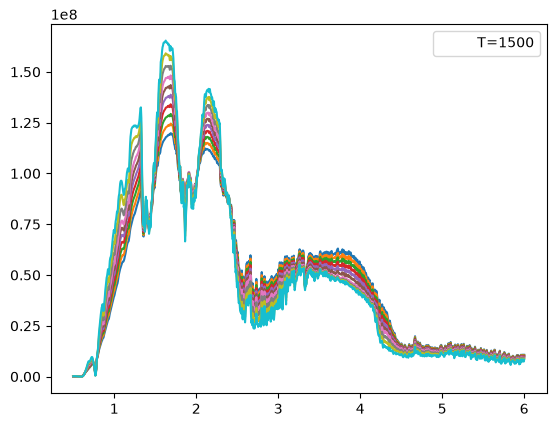

In [10]:
# Keep the same constants!
mask2 = (models["enrich"] == -0.00) & (models["logg"] == 4.5)

# Apply masks and create our input vectors for the rectangular grind interpolator!
masked_df_2 = models[mask2]
teff_vector = np.sort(pd.unique(masked_df_2["teff"]))
z_vector = np.sort(pd.unique(masked_df_2["z"]))

# Sort the values again!
sorted_flux_df = masked_df_2.sort_values(by=["teff", "z"])
print(sorted_flux_df)
sorted_flux_array = np.array(sorted_flux_df["flux"])

stacked_flux_array = np.stack(sorted_flux_array)

reshaped_flux = stacked_flux_array.reshape(teff_vector.shape[0], z_vector.shape[0], wave.value.shape[0], order="C")
reshaped_flux.shape

interp_2 = scipy.interpolate.RegularGridInterpolator((teff_array, z_vector), values=reshaped_flux)


test_z = np.linspace(-0.35, .3, 10)
for z in test_z:
    florp = interp_2((1500, z))
    plt.plot(wave_array, florp)

plt.plot([], [], alpha=0, label="T=1500")
plt.xlabel
plt.legend()

In [28]:
for i in range(len(inter_columns)):
    print(f"The {inter_columns[i]} is shape {inter_vector_shapes[i]}, with values {inter_vectors[i]}")

The enrich is shape 8, with values [-0.05 -0.    0.1   0.15  0.2   0.3   0.35  0.4 ]
The logg is shape 9, with values [2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ]
The teff is shape 34, with values [ 700.  800.  900. 1000. 1100. 1200. 1300. 1400. 1500. 1600. 1700. 1800.
 1900. 2000. 2100. 2200. 2300. 2400. 2500. 2600. 2700. 2800. 2900. 3000.
 3100. 3200. 3300. 3400. 3500. 3600. 3700. 3800. 3900. 4000.]
The z is shape 13, with values [-2.4  -2.2  -1.95 -1.75 -1.5  -1.3  -1.1  -0.85 -0.6  -0.35 -0.15  0.1
  0.3 ]


# Making a front to back interpolating function!

Okay now that we know the interpolation function works and we can get new models from it, lets make an all purpose function which takes in a model and wavelength range and returns a callable interpolated parameter space!

In [ ]:
models, wave = ucdmcmc.getModelSet(modelset='sand24',instrument='JWST-NIRSPEC-PRISM')
models

columns = models.columns

inter_columns = []
inter_vectors = []
inter_vector_shapes = []
for column in columns:
    if models[column].dtype == np.float64 and column != "flux":
        vector = np.sort(pd.unique(models[column]))

        inter_columns.append(column)
        inter_vectors.append(vector)
        inter_vector_shapes.append(vector.shape[0])

for i in range(len(inter_columns)):
    print(f"The {inter_columns[i]} is shape {inter_vector_shapes[i]}, with values {inter_vectors[i]}")


stacked_flux_array = np.stack(sorted_flux_array)

reshaped_flux_array = stacked_flux_array.reshape((inter_vector_shapes + [wave.value.shape[0]]), order="C")

interpolator = scipy.interpolate.RegularGridInterpolator(inter_vectors, values=reshaped_flux_array)

,model,enrich,logg,teff,z,flux


In [ ]:
sorted_flux_array = np.array(models.sort_values(by=inter_columns)["flux"])
np.isnan(models.sort_values(by=inter_columns)["enrich"]).any()


mask = (models["enrich"] == -0.05) & (models["logg"] == 2) & (models["teff"] == 700) & (models["z"] == -2.4)
models[mask]

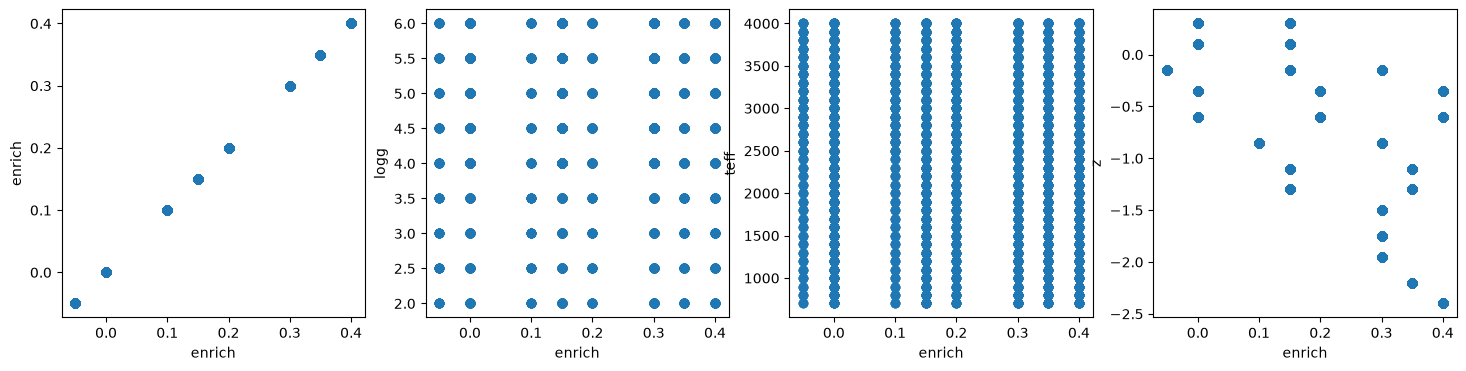

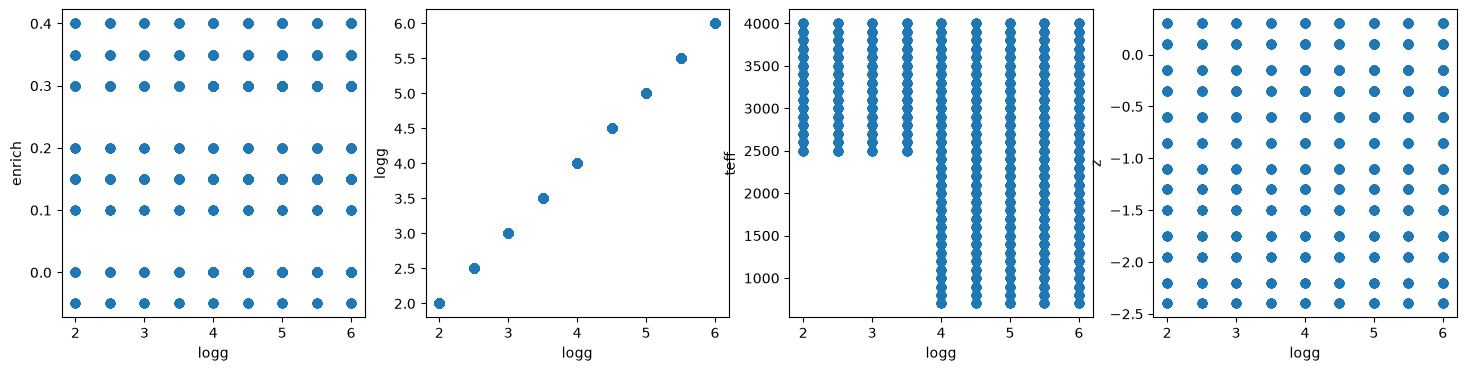

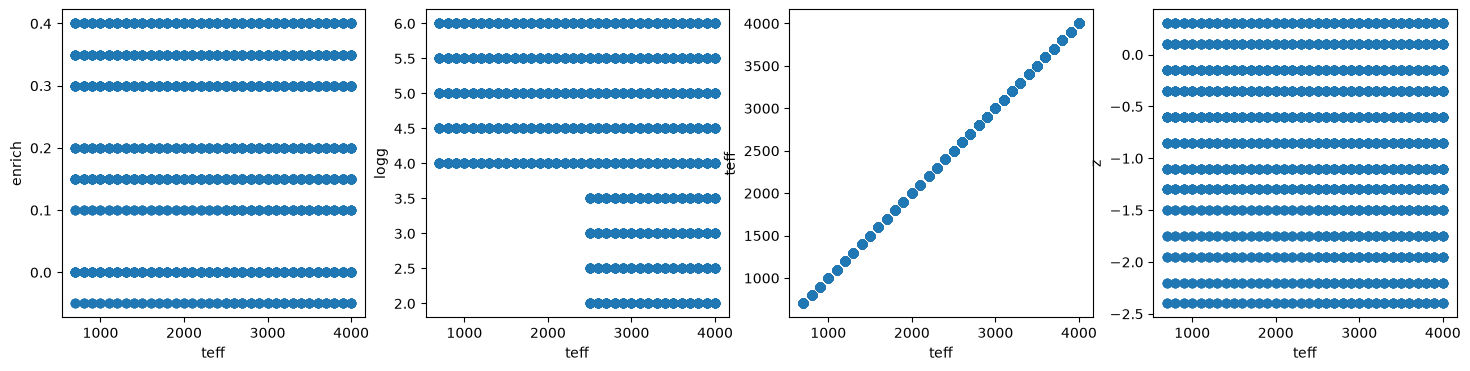

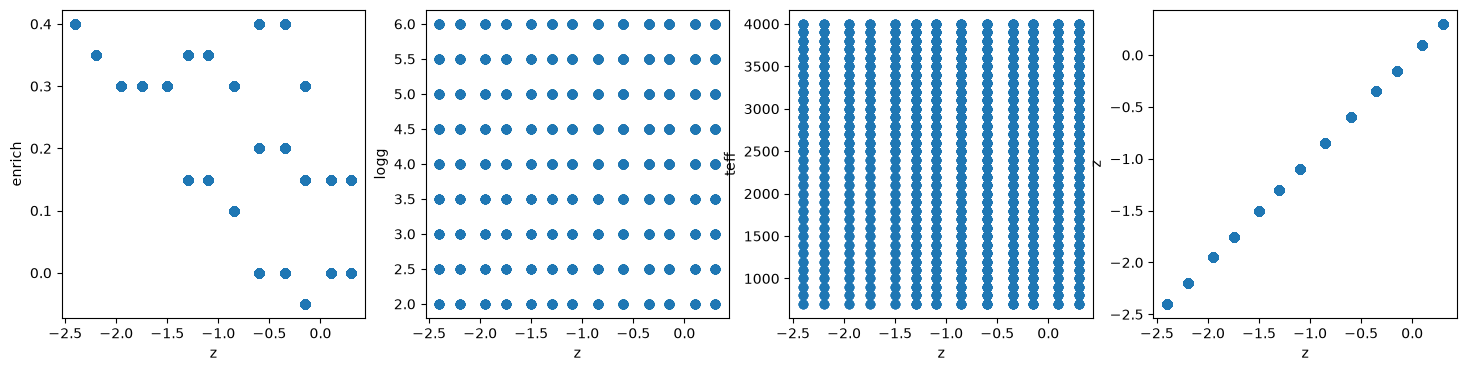

In [63]:
for i, column1 in enumerate(inter_columns):
    counter = 0 
    fig, axs = plt.subplots(1, 4, figsize=(18, 4)) 

    for j, column2 in enumerate(inter_columns):
        # fig, axs = plt.subplots(1, 4, figsize=(9, 3)) 
        axs[counter].scatter(models[column1], models[column2], alpha=0.75)
        axs[counter].set_xlabel(column1)
        axs[counter].set_ylabel(column2)
        counter += 1
        
        # plt.xlabel(inter_columns[i])
        # plt.legend()



# Well this is awkward...
This interpolation method specifically requires uniformly filled parameter grids but the plots above show some pairs of parameters sparsely filled and not rectangular...

Tomorrow Imma try using the LinearNDinterpolator function?

# Hi we're back (7/1/2026):
First before fiddling with new interpolation functions, lets see what UCDmcmc's interp. function spits out

Reading in sample spectrum for instrument JWST-NIRSPEC-PRISM of source Wolf 1130C

Best parameters:
	model = sand24
	enrich = -0.0
	logg = 5.5
	teff = 700.0
	z = -0.6
	scale = 8.707784713710859e-21
	chis = 1666629.4543973024
	radius = 0.04138875697725068
	dof = 745.0
	rchi = 2237.086515969533


<Figure size 640x480 with 0 Axes>

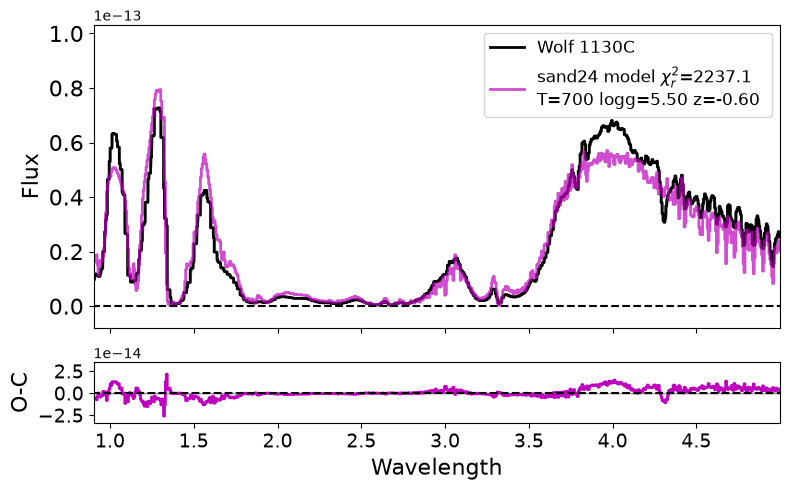

<bound method Spectrum.plot of  spectrum of sand24 model: model=sand24 enrich=-0.0 logg=5.505 teff=701.0 z=-0.5975 scale=8.707784713710859e-21 chis=1666629.4543973024 radius=0.04138875697725068 dof=745.0 rchi=2237.086515969533 >

In [55]:
models, wave = ucdmcmc.getModelSet(modelset='sand24',instrument='JWST-NIRSPEC-PRISM')

sp = ucdmcmc.getSample(instrument='JWST-NIRSPEC-PRISM')
sp.trim([0.9,5])
sp.toWavelengths(wave)

par = ucdmcmc.fitGrid(sp, models)
glorp = ucdmcmc.getInterpModel(models, par, wave)
glorp = ucdmcmc.getInterpModel(models, glorp.parameters, wave)
glorp.plot

In [13]:
m_min = 0.
m_max = 100.
b_min = 0.
b_max = 100.

def log_prior(theta):
    """
    Returns log(prior) for a given parameter vector
    
    Parameters
    ----------
    theta: list, array-like
        List of parameters in the form [slope, intercept]
    
    Returns
    -------
    ln_prior: float
        Natural log of the prior probability function
    """
    m, b = theta

    m_mask = (m > m_min) & (m < m_max)

    b_mask =  (b > b_min) & (b < b_max)

    ln_prior = np.log(np.where(0, 1, m_mask) * np.where(0, 1, b_mask))

    return ln_prior


def log_likelihood(theta, y, dy):
    """Returns log(likelihood) for a given vector / grid of parameters, range of input values, x, range of data values, y, with corresponding errors, dy. 
    
    Parameters
    ----------
    theta: list, array-like
        List of parameters in the form [slope, intercept]

    x: list, array-like
        List of input values for the model, y = mx + b

    y: list, array-like
        List of data values

    dy: list, array-like
        List of error bars for data values, y
    
    Returns
    -------
    ln_likelihood: float or array of floats
        Natural log of the likelihood function"""
    

    # If theta is a single (m, b) pair, 

    # m, b = theta

    # model = (m[..., np.newaxis] * x) + b[..., np.newaxis]
    model = interp_nd(theta)
    if not np.all(np.isfinite(model)):
        return -np.inf
    
    return np.nansum((-0.5) * (np.log(2*np.pi*dy**2) + ((y - model[1]) / dy)**2), axis=-1)


def log_posterior(theta, x, y, dy):
    """Returns log(posterior) for a given vector / grid of parameters, range of input values, x, range of data values, y, with corresponding errors, dy. 
    
    Parameters4xr
    ----------
    theta: list, array-like
        List of parameters in the form [slope, intercept]

    x: list, array-like
        List of input values for the model, y = mx + b

    y: list, array-like
        List of data values

    dy: list, array-like
        List of error bars for data values, y
    
    Returns
    -------
    ln_prior: float or array of floats
        Natural log of the prior probability function"""

    ln_likelihood = log_likelihood(theta, x, y, dy)
    ln_prior = log_prior(theta)

    return ln_likelihood + ln_prior

Reading in sample spectrum for instrument JWST-NIRSPEC-PRISM of source Wolf 1130C

Best parameters:
	model = sand24
	enrich = -0.0
	logg = 5.5
	teff = 700.0
	z = -0.6
	scale = 8.694220419439174e-21
	chis = 1698472.4857372243
	radius = 0.04135650835732211
	dof = 771.0
	rchi = 2202.94745231806


<Figure size 640x480 with 0 Axes>

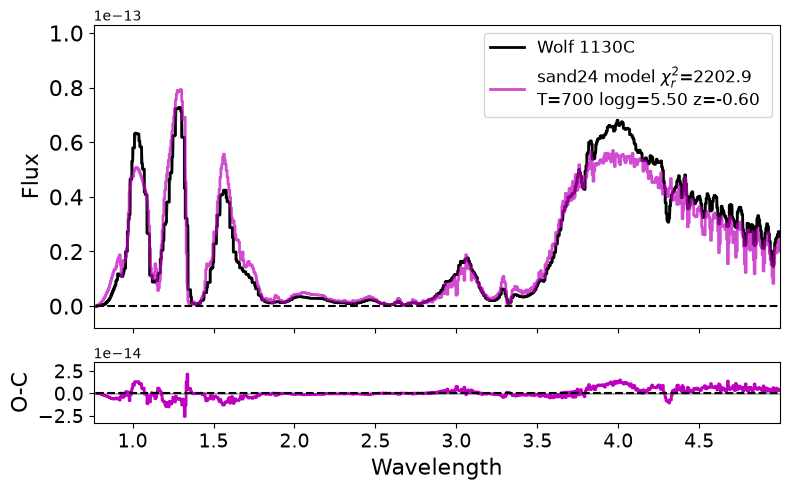

array([1.44424601e+09, 3.07620556e+09, 3.28925188e+09, ...,
       4.94016348e+07, 4.73920485e+07, 4.74643245e+07])

In [ ]:
models, wave = ucdmcmc.getModelSet(modelset='sand24',instrument='JWST-NIRSPEC-PRISM')
wave_array = wave.value

sp = ucdmcmc.getSample(instrument='JWST-NIRSPEC-PRISM')
sp.trim([0.75,5])
sp.toWavelengths(wave)

par = ucdmcmc.fitGrid(sp, models)
best_fit_model = ucdmcmc.getGridModel(models, par, wave)

chi,scl,dof = ucdmcmc.compareSpec(sp.flux,best_fit_model.flux,sp.noise)
# scl
# dof = dof-nparam
# best_fit_model.scale(scl)

In [130]:
par["teff"] = 705
forp = ucdmcmc.getModel(models, par, wave)
forp

 spectrum of sand24 model: model=sand24 enrich=-0.0 logg=5.505 teff=705 z=-0.5975 scale=8.694220419439174e-21 chis=1698472.4857372243 radius=0.04135650835732211 dof=771.0 rchi=2202.94745231806 

In [98]:
param_values = np.stack(models["flux"].to_numpy())
# print(param_values)
print(sp.flux.value[80:100])
gorp = param_values * scl
gorp
best_fit_model.flux

[1.08947904e-14 1.20173158e-14 1.35031476e-14 1.38663490e-14
 2.00259976e-14 2.00259976e-14 2.72671069e-14 3.16801503e-14
 3.35570907e-14 4.64786073e-14 4.64786073e-14 5.30523687e-14
 5.79676710e-14 5.79676710e-14 6.31238049e-14 6.33547593e-14
 6.32607056e-14 6.30207315e-14 6.30207315e-14 6.04685527e-14]


<Quantity [5.82715726e-18, 7.76804419e-18, 4.82182898e-18, ...,
           2.35440739e-15, 2.42982398e-15, 4.06815344e-15] erg / (micron s cm2)>

In [91]:
scl

0.9999999999999998

Reading in sample spectrum for instrument JWST-NIRSPEC-PRISM of source Wolf 1130C

Best parameters:
	model = sand24
	enrich = -0.0
	logg = 5.5
	teff = 700.0
	z = -0.6
	scale = 8.694220419439174e-21
	chis = 1698472.4857372243
	radius = 0.04135650835732211
	dof = 771.0
	rchi = 2202.94745231806


<Figure size 640x480 with 0 Axes>

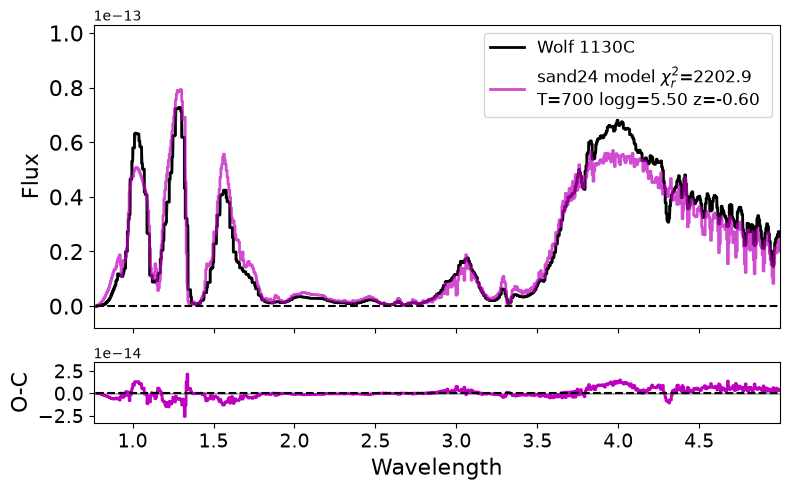

State([[ 2.69177070e-01  5.46732590e+00  7.00000066e+02 -7.72949314e-01]
 [ 2.69007167e-01  5.46715356e+00  7.00000033e+02 -7.72588472e-01]
 [ 2.69144802e-01  5.46763806e+00  7.00000027e+02 -7.72868171e-01]
 [ 2.69294931e-01  5.46684529e+00  7.00000006e+02 -7.73241311e-01]
 [ 2.69167277e-01  5.46718018e+00  7.00000027e+02 -7.72949924e-01]
 [ 2.69178302e-01  5.46707716e+00  7.00000003e+02 -7.72962075e-01]
 [ 2.69141807e-01  5.46720122e+00  7.00000003e+02 -7.72862451e-01]
 [ 2.69145776e-01  5.46725345e+00  7.00000024e+02 -7.72987958e-01]
 [ 2.69143541e-01  5.46723012e+00  7.00000022e+02 -7.72886446e-01]
 [ 2.69131312e-01  5.46709221e+00  7.00000018e+02 -7.72853217e-01]], log_prob=[-1131547.58110062 -1131548.66611721 -1131547.23689224 -1131545.7899954
 -1131546.45825322 -1131545.07577232 -1131544.66844696 -1131549.12307322
 -1131546.0340977  -1131545.92024448], blobs=None, random_state=('MT19937', array([2591470055, 1272969946, 2283739268, 3655825510, 2421701608,
       4186903972, 276102

In [114]:
models, wave = ucdmcmc.getModelSet(modelset='sand24',instrument='JWST-NIRSPEC-PRISM')
wave_array = wave.value

sp = ucdmcmc.getSample(instrument='JWST-NIRSPEC-PRISM')
sp.trim([0.75,5])
sp.toWavelengths(wave)

par = ucdmcmc.fitGrid(sp, models)
scale = par["scale"]

columns = models.columns

inter_columns = []
for column in columns:
    if models[column].dtype == np.float64 and column != "flux":
        inter_columns.append(column)

param_points = models[inter_columns].to_numpy()
param_values = np.stack(models["flux"].to_numpy())
param_values = param_values * scale

interp_nd = scipy.interpolate.LinearNDInterpolator(param_points, param_values, rescale=True)

def log_likelihood(theta, y, dy):
    """Returns log(likelihood) for a given vector / grid of parameters, range of input values, x, range of data values, y, with corresponding errors, dy. 
    
    Parameters
    ----------
    theta: list, array-like
        List of parameters in the form [slope, intercept]

    x: list, array-like
        List of input values for the model, y = mx + b

    y: list, array-like
        List of data values

    dy: list, array-like
        List of error bars for data values, y
    
    Returns
    -------
    ln_likelihood: float or array of floats
        Natural log of the likelihood function"""
    

    # If theta is a single (m, b) pair, 

    # m, b = theta

    # model = (m[..., np.newaxis] * x) + b[..., np.newaxis]
    model = interp_nd(theta)
    if not np.all(np.isfinite(model)):
        return -np.inf
    
    return np.nansum((-0.5) * (np.log(2*np.pi*dy**2) + ((y - model[0]) / dy)**2), axis=-1)


n_walkers=10
rng = np.random

enr_random = rng.uniform(low=.15, high=.4, size=n_walkers)
logg_random = rng.uniform(low=2, high=6, size=n_walkers)
teff_random = rng.uniform(low=700, high=4000, size=n_walkers)
z_random = rng.uniform(low=-1.3, high=0.3, size=n_walkers)

# Above we initilizes to separate 1D arrays, now we will just concatenate them together, giving them a 2x100 array! 
initial_guesses = np.array([enr_random, logg_random, teff_random, z_random])



glorp = emcee.EnsembleSampler(n_walkers, 4, log_likelihood, args=(sp.flux.value, sp.noise.value))
glorp.run_mcmc(initial_guesses.T, 10000)

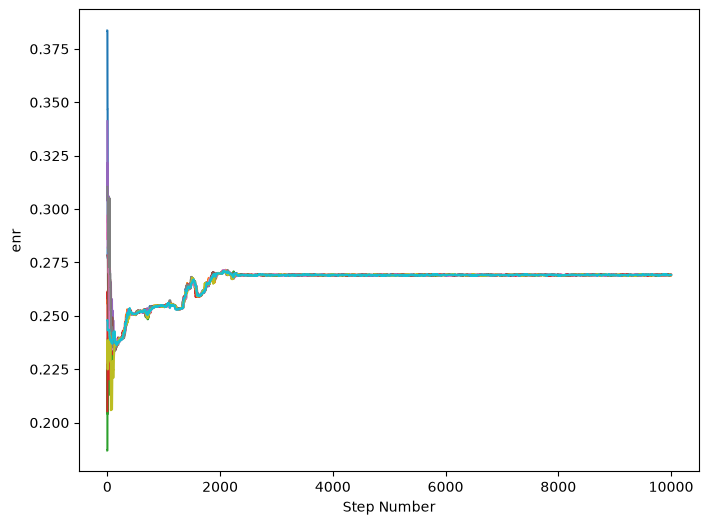

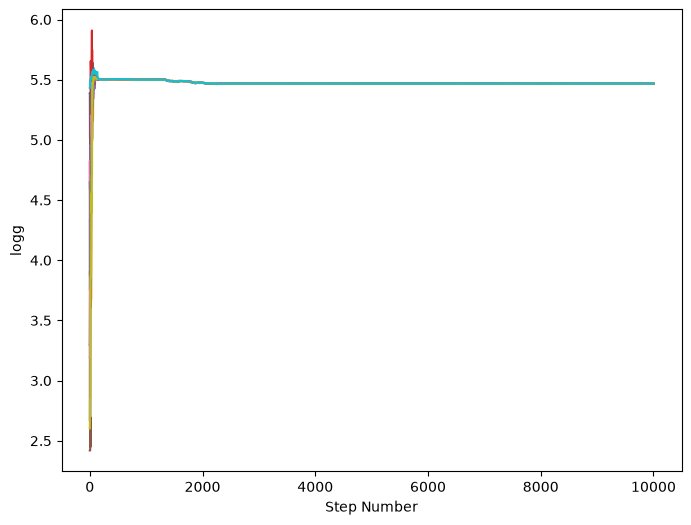

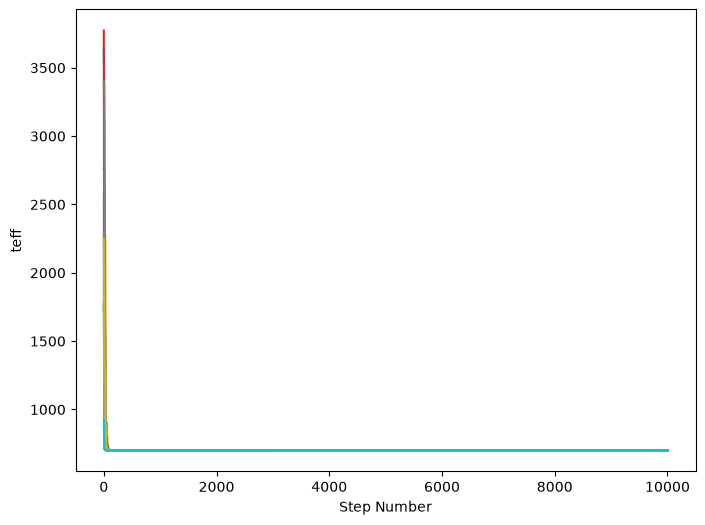

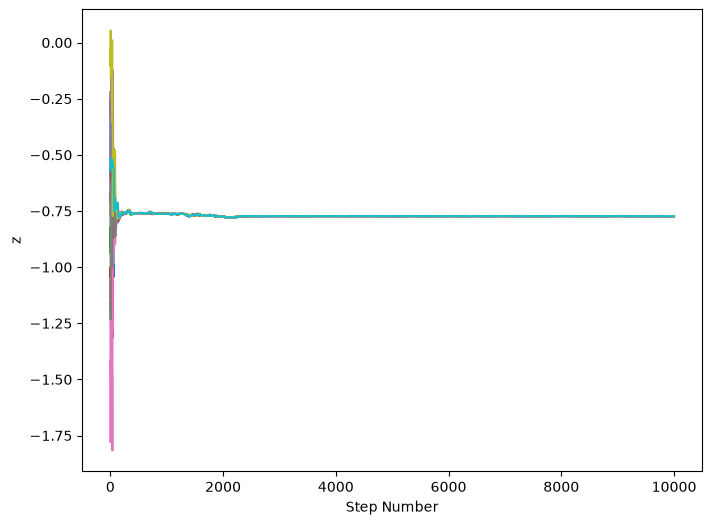

In [115]:
def chain_plots(chain, **kwargs):
    """
    Plot the histories for each walker in sampler.chain
    
    Parameters
    ----------
    chain: ndarray
        3D array given by sampler.flatchain, with shape (n_walkers, n_steps, n_params)
    kwargs: `.Line2D` properties, optional
        All keyword arguments are passed to `pyplot.plot`
    """
    
    enr_chain = chain[:,:,0]
    logg_chain = chain[:,:,1]
    teff_chain = chain[:,:,2]
    z_chain = chain[:,:,3]

    plt.figure(figsize=(8,6))
    plt.plot(enr_chain.T) 
    plt.xlabel('Step Number')
    plt.ylabel('enr')

    plt.figure(figsize=(8,6))
    plt.plot(logg_chain.T) 
    plt.xlabel('Step Number')
    plt.ylabel('logg')

    plt.figure(figsize=(8,6))
    plt.plot(teff_chain.T) 
    plt.xlabel('Step Number')
    plt.ylabel('teff')

    plt.figure(figsize=(8,6))
    plt.plot(z_chain.T) 
    plt.xlabel('Step Number')
    plt.ylabel('z')
    
chain_plots(glorp.chain)

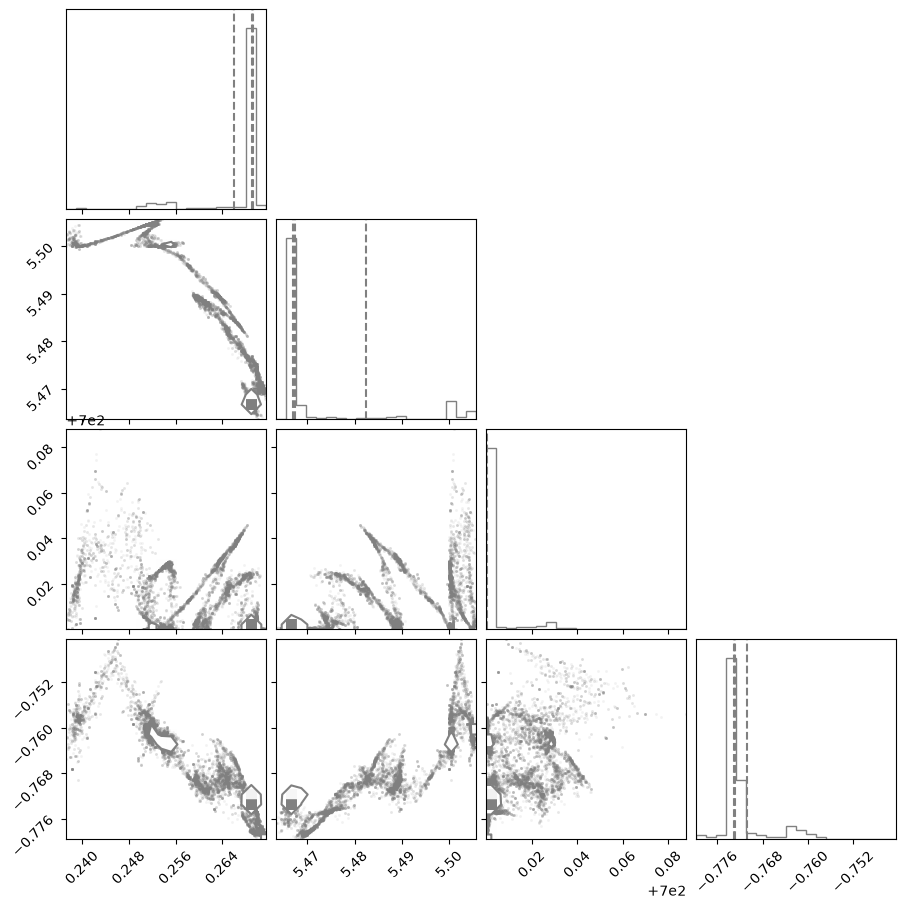

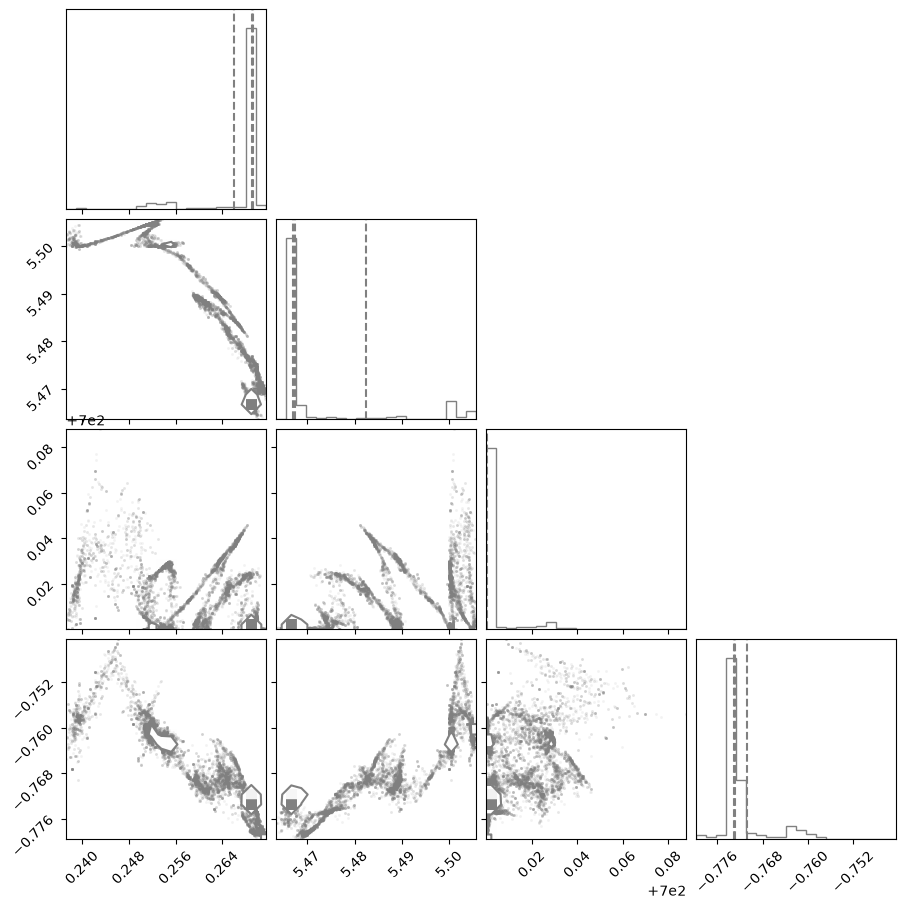

In [116]:
import corner

enr_steps = glorp.flatchain[200*n_walkers:, 0]
logg_steps = glorp.flatchain[200*n_walkers:, 1]
teff_steps = glorp.flatchain[200*n_walkers:, 2]
z_steps = glorp.flatchain[200*n_walkers:, 3]

corner.corner(np.array([enr_steps, logg_steps, teff_steps, z_steps]).T, 
            #   show_titles=True, 
              color="gray", 
            #   titles=("Slope [m]", "Intercept [b]"), 
              quantiles=[0.16, .5, .84], 
              # truths=[10, 50], 
              # truth_color="#a636c2"
              )

[ 2.69100317e-01  5.46723805e+00  7.00000001e+02 -7.72751677e-01]


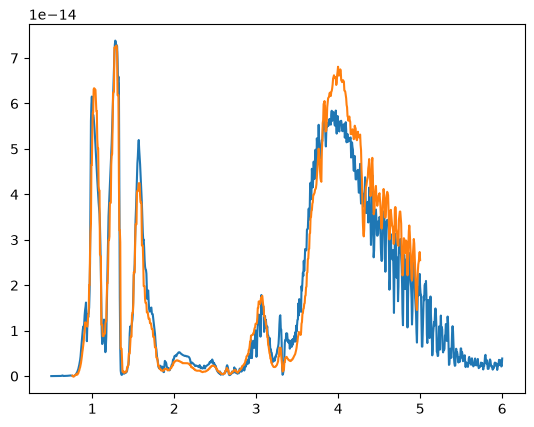

In [118]:
argmax = np.argmax(glorp.get_log_prob())
bestfit_param = glorp.flatchain[argmax]
print(bestfit_param)

fleep = interp_nd(bestfit_param)
# fleep_norm = fleep[0, :] / (np.nanmax(fleep[0,:]))
# sp_norm = sp.flux.value / (np.nanmax(sp.flux.value))
# plt.plot(wave_array, fleep_norm)
# plt.plot(sp.wave.value, sp_norm)

plt.plot(wave_array, fleep[0,:])
plt.plot(sp.wave.value, sp.flux.value)

plt.show()

In [ ]:
def fitEMCEE(spc,models,p0={},plimits={},output='all', flux_name=DEFAULT_FLUX_NAME,
	pstep=DEFAULT_MCMC_STEPS,nstep=100,iterim=50,method='chidiff',threshhold=0.5,burn=0.25,propose_scale=1.1,
	quantscale=[0.25,0.5,0.75],nsample=0,absolute=False,report=True,xscale='linear',yscale='linear',
	file_prefix='emceefit_',verbose=ERROR_CHECKING):

	# make sure object spectrum is sampled to same wavelength scale as models
#	print(constraints,plimits)
	if len(spc.flux)!=len(models.loc[0,flux_name]):
		raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
	spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
	if len(list(constraints.keys()))>0:
#		print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
		plimits = copy.deepcopy(constraints)

# constrain models if needed
	mdls = copy.deepcopy(models)
	for k in list(plimits.keys()):
		if k in list(mdls.columns):
			if isinstance(mdls.loc[0,k],str):
				if len(plimits[k])>0:
					par = list(set(list(mdls[k])))
#					print(k,par,plimits[k])
					if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
					for p in par:
						if p not in plimits[k]: 
							mdls = mdls[mdls[k]!=p]
							mdls.reset_index(inplace=True,drop=True)
			else:
				if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
				mdls = mdls[mdls[k]>=plimits[k][0]]
				mdls = mdls[mdls[k]<=plimits[k][1]]
				mdls.reset_index(inplace=True,drop=True)
	mset = mdls.loc[0,'model']
	mkys = list(mdls.keys())
	for x in ['model','file',flux_name]:
		if x in mkys: mkys.remove(x)

# if no or incomplete fit parameters, conduct an initial grid fit
	chk = True
	for k in mkys: chk=(chk and (k in list(p0.keys())))
	if chk==False:
		if verbose==True: print('Running initial grid fit')
		p0 = fitGrid(spc,mdls,absolute=absolute,plimits=plimits,report=False,verbose=False)
		if flux_name in list(p0.keys()): del p0[flux_name]
		if verbose==True: print('\nGrid fit parameters: {}'.format(p0))

# determine the model parameters that can be varied
	mkysfit = copy.deepcopy(mkys)
	for x in ['file','model','scale','dof','rchi']:
		if x in mkysfit: mkysfit.remove(k)
	for k in mkys:
		vals = list(set(list(mdls[k])))
		vals.sort()
		if len(vals)<2: pstep[k] = 0.
		else:
			if k not in list(pstep.keys()):
				if isinstance(vals[0],str): pstep[k] = -1.
				else: pstep[k] = 0.5*np.nanmedian(np.absolute(np.array(vals)-np.roll(vals,1)))
		if pstep[k] == 0: mkysfit.remove(k)

# add in alternate parameters if present
	for k in ALT_PARAMETERS:
		if k in list(p0.keys()):
			if k not in list(pstep.keys()): pstep[k] = 0
			if pstep[k] > 0: 
				mkysfit.append(k)
	nparam = len(mkysfit)

# set defaults for required model parameters
	for k in mkysfit: 
		if k not in list(p0.keys()):
			if k in list(mdls.columns): p0[k] = DEFINED_SPECTRAL_MODELS[mset]['default'][k]
			elif k in list(PARAMETERS.keys()): p0[k] = PARAMETERS[k]['default']
			else: 
				if verbose==True: print('Warning: dropping parameter {} as no default value provided'.format(k))
				mkysfit.remove(k)
				nparam = len(mkysfit)

# set limits for fitting parameters
	for k in mkysfit: 
		if k not in list(plimits.keys()):
			if k in list(mdls.columns): 
				vals = list(set(list(mdls[k])))
				vals.sort()
				if isinstance(vals,str)==False: plimits[k] = [vals[0],vals[-1]]
				else: plimits[k] = vals
			elif k in list(PARAMETERS.keys()): plimits[k] = PARAMETERS[k]['limits']
			else: plimits[k] = [p0[k],p0[k]]

# organize into continuous and discrete variables
	pfitc,pfitd = {},{}
	if verbose==True: print('Fitting the following parameters:')
	for k in mkysfit: 
		if k in list(p0.keys()):
			if isinstance(p0[k],str)==True: 
				pfitd[k] = p0[k]
				if verbose==True: print('\t{}: initial={} (discrete)'.format(k,p0[k]))
			else: 
				pfitc[k] = p0[k]
				if verbose==True: print('\t{}: initial={} step={} min={} max={}'.format(k,p0[k],pstep[k],plimits[k][0],plimits[k][1]))
# 		else: 
# 			if k in list(PARAMETERS.keys()):

# 				if PARAMETERS[k]['type'] == str: p
# 				else: pfitc[k] = p0[k]
# 			elif k in list(mdls.columns):
# 				if isinstance(mdls.loc[0,k],str): pfitd[k] = p0[k]
# 				else: pfitc[k] = p0[k]
# 			else: 
# 			default = DEFINED_SPECTRAL_MODELS[mset]['default'][k]
# #			default = splat.SPECTRAL_MODELS[mset]['default'][k]
# 			if isinstance(default,str): pfitd[k] = default
# 			else: pfitc[k] = default

# some plotting set up
	ylabelpre = 'Scaled '
	if absolute==True: ylabelpre='Absolute '

# initialize MCMC
	cmdl = getModel(mdls,p0,spscl.wave,scale=False,verbose=verbose)
	chi,scl,dof = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
	dof = dof-nparam
	cmdl.scale(scl)
	chis = [chi]
	pvals = [p0]
	mdlflxs = [cmdl.flux.value]
	scales = [scl]

# run MCMC
	if verbose==True: print('Running MCMC for {:.0f} steps'.format(nstep))
	for i in tqdm(range(nstep)):
		pnew = copy.deepcopy(pvals[-1])
# continuous variables		
# constrain to be within specified limits
		for k in list(pfitc.keys()): 
			pnew[k] = np.random.normal(pvals[-1][k],pstep[k])
			pnew[k] = np.nanmin([pnew[k],np.nanmax(plimits[k])])
			pnew[k] = np.nanmax([pnew[k],np.nanmin(plimits[k])])
# discrete variables
		for k in list(pfitd.keys()): 
#			vals = list(set(list(mdls[k])))
			pnew[k] = np.random.choice(plimits[k])
# do we need this next line?			
#		pnew = pnew | pfitd
# try grid model			
		try:
			cmdl = getModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# try interpolated model			
		# except:
		# 	cmdl = getInterpModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# model can't be read, stay in place
		except: 
			if verbose==True: print('Error reading in parameters {}'.format(pnew))
			pvals.append(pvals[-1])
			chis.append(chis[-1])
			scales.append(scales[-1])
			mdlflxs.append(mdlflxs[-1])
# compare model			
		else:
#			if verbose==True: print(i,pnew)
			chinew,scl,_ = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
			# if np.isnan(radius)==False and np.isnan(e_radius)==False:
			#	 chinew+=(((10.*u.pc*(scl**0.5)).to(u.Rsun).value-radius)/e_radius)**2
			#if 'scale' not in list(pnew.keys()): cmdl.scale(scl)

	# compute statistic
			if method=='chidiff': st,chst = (chinew-chis[-1])/np.nanmin(chis),np.random.uniform(0,threshhold)
			elif method=='survival': st,chst = 2*stats.f.sf(chinew/chis[-1],dof,dof),np.random.uniform(threshhold,1)
			elif method=='dofscale': st,chst = dof/(0.5*dof+chinew-chis[-1]),np.random.uniform(threshhold,1)
			else: raise ValueError('Do not recognize statistical comparison {}; try chidiff, survival, or dofscale'.format(method))
	#			if verbose==True: print(chinew,chis[-1],dof,st,chst)

			if st<chst:
	# reset if we've wandered off
				if chinew>(1+2*threshhold)*np.nanmin(chis):
					if verbose==True: print('RESETING TO BEST FIT')
					pvals.append(pvals[np.argmin(chis)])
					chis.append(chis[np.argmin(chis)])
					scales.append(scales[np.argmin(chis)])
					mdlflxs.append(mdlflxs[np.argmin(chis)])
	# criterion satisfied, make a move
				else:
					if verbose==True: print('CHANGED PARAMETERS!')
					pvals.append(pnew)
					chis.append(chinew)
					scales.append(scl)
					mdlflxs.append(cmdl.flux.value)
	# criterion not satisfied, stay in place
			else:
				pvals.append(pvals[-1])
				chis.append(chis[-1])
				scales.append(scales[-1])
				mdlflxs.append(mdlflxs[-1])
# iterim save
		if iterim>0 and i>0 and np.mod(i,iterim)==0 and report==True:
# save parameters
			dpfit = pandas.DataFrame()
			for k in list(pvals[0].keys()): 
				dpfit[k] = [p[k] for p in pvals]
			dpfit['chis'] = chis
			dpfit['dof'] = [dof]*len(dpfit)
			dpfit['scale'] = scales
			dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]
			outfile = file_prefix+'_parameters.xlsx'
			dpfit.to_excel(outfile,index=False)
# plot comparison
			if verbose==True: print('Saving iterim plots')
			pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
#			pbest['radius'] = (10.*u.pc*(scales[np.argmin(chis)]**0.5)).to(u.Rsun).value
			cmdl = getModel(mdls,pbest,spscl.wave,scale=True,verbose=verbose)
			# print(scales[np.argmin(chis)],pbest['scale'],np.nanmax(cmdl.flux.value))
			# cmdl.scale(scales[np.argmin(chis)])
			# print(np.nanmax(cmdl.flux.value))
			label = '{} model '.format(mset)
			label+=r'$\chi^2_r$='+'{:.1f}\n'.format(np.nanmin(chis)/dof)
			label+='T={:.0f} '.format(pbest['teff'])
			label+='logg={:.2f} '.format(pbest['logg'])
			label+='z={:.2f} '.format(pbest['z'])
			outfile = file_prefix+'_compare.pdf'
			plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=verbose)
# plot cornerplot
			plotpars = copy.deepcopy(mkysfit)
			for k in plotpars:
				if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
			if absolute==True: plotpars.append('radius')
			pbest = {}
			for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
			weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
			outfile = file_prefix+'_corner.pdf'
			try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
			except: print('Warning: had trouble making corner plot')
# plot chains
			plotpars.append('chis')
			plotpars.append('scale')
			outfile = file_prefix+'_chains.pdf'
			plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# remove burn in
	pvalsb = pvals[int(burn*nstep):]
	dpfit = pandas.DataFrame()
	for k in list(pvalsb[0].keys()): 
		dpfit[k] = [p[k] for p in pvalsb]
	dpfit['chis'] = chis[int(burn*nstep):]
	dpfit['dof'] = [dof]*len(dpfit)
	dpfit['scale'] = scales[int(burn*nstep):]
	dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]

# best fit parameters
	pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
	pvalsb[np.argmin(chis[int(burn*nstep):])]
	for x in [flux_name,'file']:
		if x in list(pbest.keys()): del pbest[x]
	if verbose==True or report==True: 
		print('\nBest parameters:')
		for x in list(pbest.keys()): print('\t{}: {}'.format(x,pbest[x]))
	cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
	if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])

# distribution of values
	pdist = {}
	dpars = copy.deepcopy(mkysfit)
	for k in dpars:
		if isinstance(pvalsb[0][k],str)==False: pdist[k] = np.nanquantile([p[k] for p in pvalsb],quantscale)
	if absolute==True: 
		pdist['radius'] = np.nanquantile([(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in scales[int(burn*nstep):]],quantscale)

	if report == True:
# remove initial burn and save
		outfile = file_prefix+'_parameters.xlsx'
		if verbose==True: print('Saving database of prameters to {}'.format(outfile))
		dpfit.to_excel(outfile,index=False)
# plot comparison
		# cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
		# if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])
		label = '{} model '.format(mdls.loc[0,'model'])
		label+=r'$\chi^2_r$='+'{:.1f}\n'.format(chis[np.argmin(chis)]/dof)
		label+='T={:.0f} '.format(pbest['teff'])
		label+='logg={:.2f} '.format(pbest['logg'])
		label+='z={:.2f} '.format(pbest['z'])
		outfile = file_prefix+'_compare.pdf'
		if verbose==True: print('Plotting best fit comparison to {}'.format(outfile))
		if nsample<=0: 
			plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
		else:
			plotCompareSample(spscl,mdls,dpfit,nsample=nsample,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
# plot cornerplot
		plotpars = copy.deepcopy(mkysfit)
		for k in plotpars:
			if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
		if absolute==True: plotpars.append('radius')
		pbest = {}
		for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
		weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
		outfile = file_prefix+'_corner.pdf'
		if verbose==True: print('Plotting corner plot to {}'.format(outfile))
		try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
		except: print('Warning: had trouble making corner plot')
# plot chains
		plotpars.append('chis')
		plotpars.append('scale')
		outfile = file_prefix+'_chains.pdf'
		if verbose==True: print('Plotting chain plot to {}'.format(outfile))
		plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# return depending on output keyword
	if 'best' in output.lower(): return pbest
	elif 'spec' in output.lower(): return cmdl
	elif 'dist' in output.lower(): return pdist
	elif 'chain' in output.lower(): return pandas.DataFrame(pvalsb)
	else:
		return {'best': pbest, 'model': cmdl, 'distributions': pdist, 'chain': pandas.DataFrame(pvalsb)}



	return